In [2]:
%pip install seaborn matplotlib dotenv psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.3 MB 1.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.3 MB 1.5 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.3 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.3 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.3 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.4 MB/s eta 0:00:04
   --------------- ------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# Connexion et chargement
load_dotenv(dotenv_path=r"C:\Users\Samsung\Desktop\Projet_&_cours_eigsi\collecte&explorationdonnées\ImmoVision360_DataLake\.env")
engine = sqlalchemy.create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

# On crée la variable 'df' ici
df = pd.read_sql("SELECT * FROM elysee_listings_silver", engine)

# Remplissage par -1 comme demandé pour le Bloc B
df = df.fillna(-1)

print("Variable 'df' prête !")

Variable 'df' prête !


In [4]:
df.head()

,id,listing_url,host_id,calculated_host_listings_count,price,property_type,room_type,availability_365,host_response_time,host_response_rate,number_of_reviews,review_scores_rating,neighbourhood_cleansed,latitude,longitude,Standardization_Score,Neighborhood_Impact
0,2871271,https://www.airbnb.com/rooms/2871271,14627960,1,-1,Entire rental unit,Entire home/apt,96,within an hour,100%,299,4.62,Élysée,48.87933,2.31491,1,1
1,2785692,https://www.airbnb.com/rooms/2785692,14099131,1,-1,Private room in tiny home,Private room,176,-1,-1,15,4.80,Élysée,48.88045,2.31161,-1,0
2,2892435,https://www.airbnb.com/rooms/2892435,14783581,2,-1,Entire rental unit,Entire home/apt,299,within an hour,100%,527,4.85,Élysée,48.87046,2.31129,0,-1
3,3015969,https://www.airbnb.com/rooms/3015969,15370031,1,-1,Private room in rental unit,Private room,0,-1,-1,0,-1.00,Élysée,48.87300,2.30406,-1,1
4,3126320,https://www.airbnb.com/rooms/3126320,11957723,1,-1,Entire rental unit,Entire home/apt,53,-1,-1,20,4.90,Élysée,48.87983,2.31621,1,-1


In [5]:
# Remplacement des valeurs manquantes par -1
# Note : Dans ce rapport, -1 signifie "Information non disponible" 
# (à ne pas confondre avec une valeur métier comme 0 jour de disponibilité).
df = df.fillna(-1)

# Vérification rapide
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2625 non-null   int64  
 1   listing_url                     2625 non-null   str    
 2   host_id                         2625 non-null   int64  
 3   calculated_host_listings_count  2625 non-null   int64  
 4   price                           2625 non-null   object 
 5   property_type                   2625 non-null   str    
 6   room_type                       2625 non-null   str    
 7   availability_365                2625 non-null   int64  
 8   host_response_time              2625 non-null   object 
 9   host_response_rate              2625 non-null   object 
 10  number_of_reviews               2625 non-null   int64  
 11  review_scores_rating            2625 non-null   float64
 12  neighbourhood_cleansed          2625 non-null

count     2625
unique       1
top         -1
freq      2625
Name: price, dtype: int64


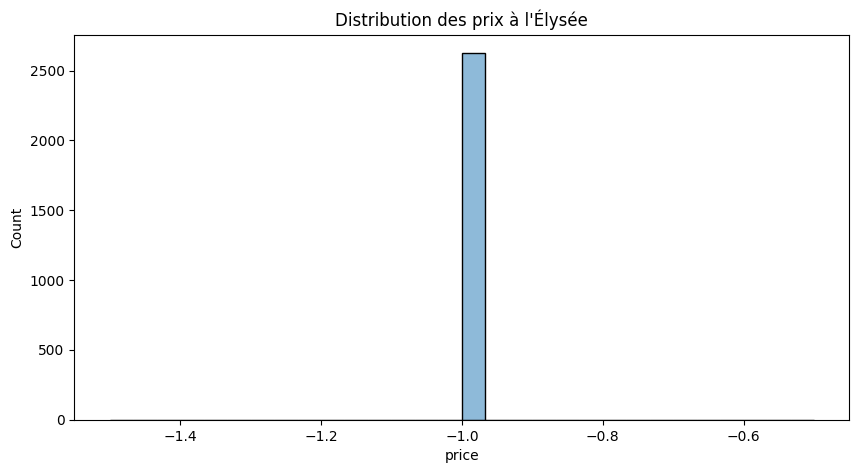

In [6]:
print(df['price'].describe()) # Affiche min, max, moyenne
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution des prix à l'Élysée")
plt.show()

Colonne trouvée : Standardization_Score

Répartition (en %) :
Standardization_Score
 0    33.638095
 1    33.561905
-1    32.800000
Name: proportion, dtype: float64


C:\Users\Samsung\AppData\Local\Temp\ipykernel_17960\2666154695.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[actual_col].map(mapping_std), palette='viridis')


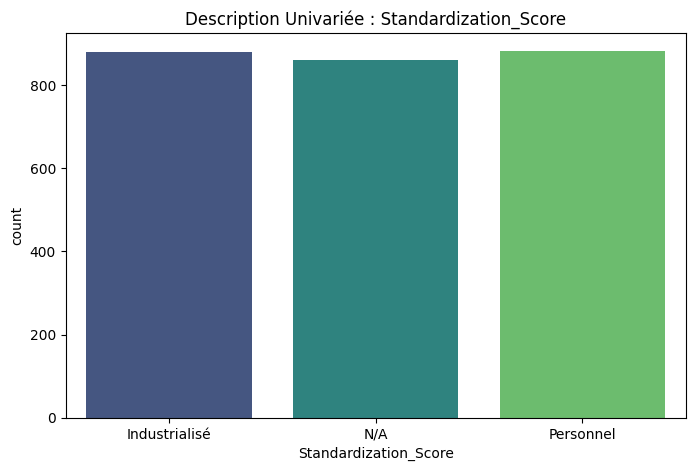

In [15]:
# On cherche le nom exact dans ton DataFrame
actual_col = None
for col in df.columns:
    if col.lower() == 'standardization_score':
        actual_col = col
        break

if actual_col:
    print(f"Colonne trouvée : {actual_col}")
    mapping_std = {1: 'Industrialisé', 0: 'Personnel', -1: 'N/A'}
    
    # Analyse univariée
    counts = df[actual_col].value_counts(normalize=True) * 100
    print(f"\nRépartition (en %) :\n{counts}")
    
    # Graphique pour ton rapport
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[actual_col].map(mapping_std), palette='viridis')
    plt.title(f"Description Univariée : {actual_col}")
    plt.show()
else:
    print("La colonne est introuvable. Voici les colonnes disponibles :")
    print(df.columns.tolist())

C:\Users\Samsung\AppData\Local\Temp\ipykernel_17960\2592309636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Neighborhood_Impact', data=df, order=df['Neighborhood_Impact'].value_counts().index, palette='viridis')


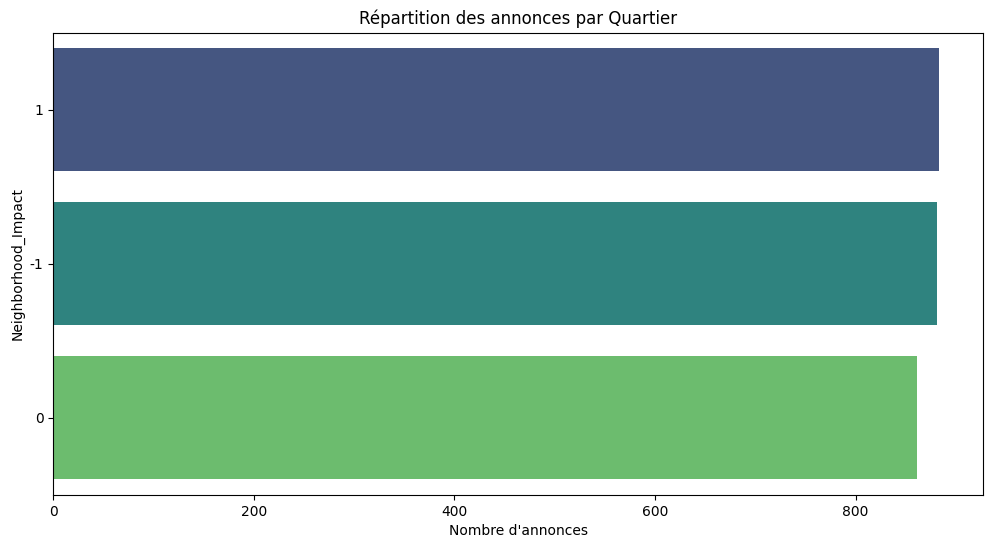

In [17]:
plt.figure(figsize=(12, 6))
# On compte les occurrences de chaque quartier
sns.countplot(y='Neighborhood_Impact', data=df, order=df['Neighborhood_Impact'].value_counts().index, palette='viridis')
plt.title("Répartition des annonces par Quartier")
plt.xlabel("Nombre d'annonces")
plt.show()

C:\Users\Samsung\AppData\Local\Temp\ipykernel_17960\3560850833.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='host_category', data=df, order=order, palette='viridis')


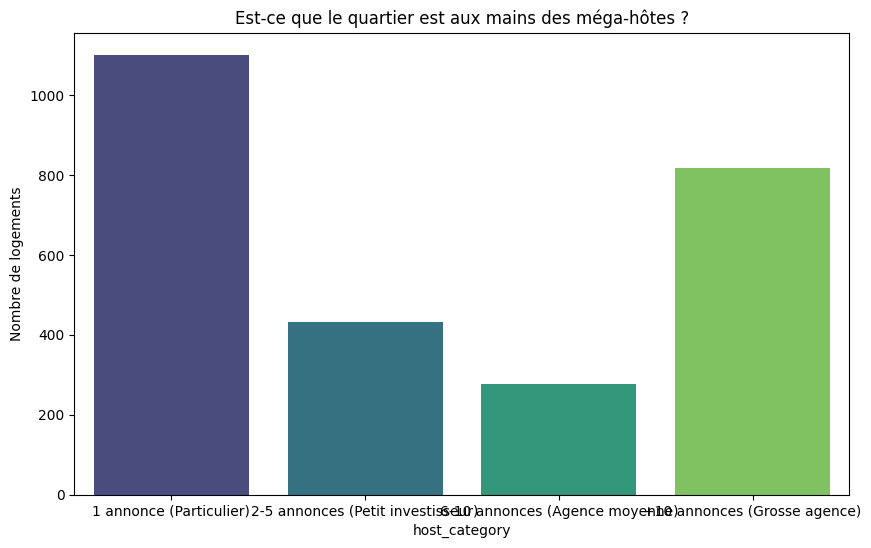

host_category
1 annonce (Particulier)              41.942857
+10 annonces (Grosse agence)         31.085714
2-5 annonces (Petit investisseur)    16.419048
6-10 annonces (Agence moyenne)       10.552381
Name: proportion, dtype: float64


In [18]:
# Création des groupes d'hôtes
def group_host(count):
    if count == 1: return "1 annonce (Particulier)"
    elif 2 <= count <= 5: return "2-5 annonces (Petit investisseur)"
    elif 6 <= count <= 10: return "6-10 annonces (Agence moyenne)"
    else: return "+10 annonces (Grosse agence)"

df['host_category'] = df['calculated_host_listings_count'].apply(group_host)

# Visualisation
plt.figure(figsize=(10, 6))
order = ["1 annonce (Particulier)", "2-5 annonces (Petit investisseur)", "6-10 annonces (Agence moyenne)", "+10 annonces (Grosse agence)"]
sns.countplot(x='host_category', data=df, order=order, palette='viridis')
plt.title("Est-ce que le quartier est aux mains des méga-hôtes ?")
plt.ylabel("Nombre de logements")
plt.show()

print(df['host_category'].value_counts(normalize=True) * 100)

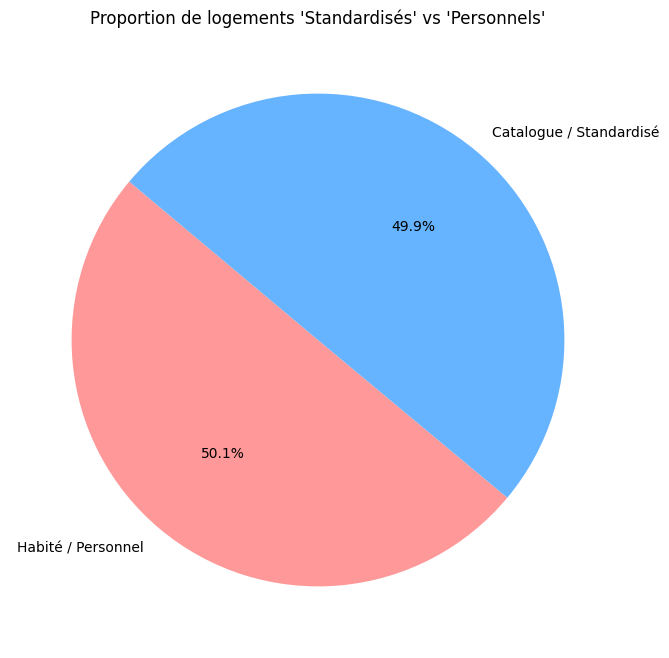

In [20]:
# Filtrer les -1 (données non disponibles)
df_aesthetic = df[df['Standardization_Score'] != -1].copy()
mapping_std = {1: 'Catalogue / Standardisé', 0: 'Habité / Personnel'}

# Graphique Camembert
data = df_aesthetic['Standardization_Score'].map(mapping_std).value_counts()
plt.figure(figsize=(8, 8))
plt.pie(data, labels=data.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title("Proportion de logements 'Standardisés' vs 'Personnels'")
plt.show()

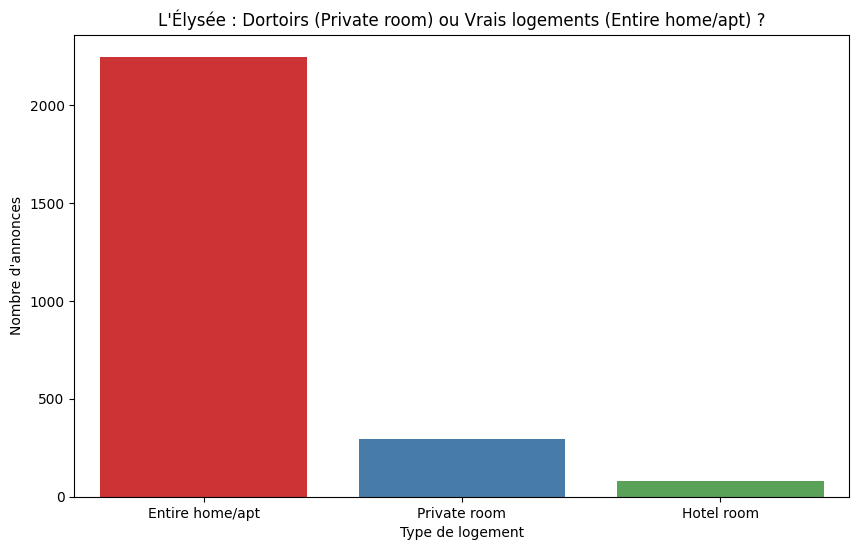

Répartition en pourcentage :
room_type
Entire home/apt    85.600000
Private room       11.314286
Hotel room          3.085714
Name: proportion, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# On nettoie les espaces éventuels et on vérifie les noms
df['room_type'] = df['room_type'].str.strip()

# Visualisation propre
plt.figure(figsize=(10, 6))

# On utilise hue=room_type pour éviter le Warning et colorer les barres
sns.countplot(
    x='room_type', 
    hue='host_is_superhost' if 'host_is_superhost' in df.columns else 'room_type',
    data=df, 
    palette='Set1'
)

plt.title("L'Élysée : Dortoirs (Private room) ou Vrais logements (Entire home/apt) ?")
plt.xlabel("Type de logement")
plt.ylabel("Nombre d'annonces")
plt.show()

# Affichage des statistiques pour ton rapport
stats = df['room_type'].value_counts(normalize=True) * 100
print("Répartition en pourcentage :")
print(stats)

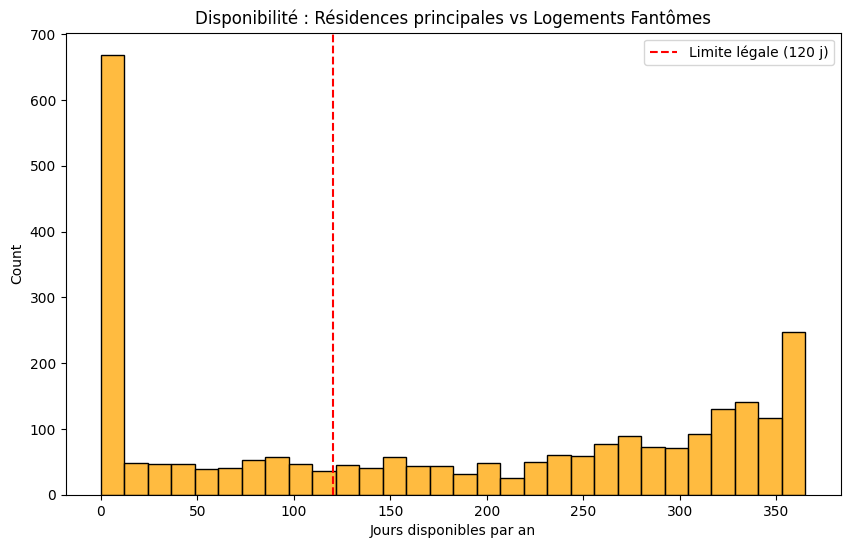

Pourcentage de 'Logements Fantômes' (>120j) : 58.97%


In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['availability_365'], bins=30, kde=False, color='orange')
# Ligne rouge pour la limite légale des 120 jours
plt.axvline(120, color='red', linestyle='--', label='Limite légale (120 j)')
plt.title("Disponibilité : Résidences principales vs Logements Fantômes")
plt.xlabel("Jours disponibles par an")
plt.legend()
plt.show()

fantomes = (df['availability_365'] > 120).sum() / len(df) * 100
print(f"Pourcentage de 'Logements Fantômes' (>120j) : {fantomes:.2f}%")

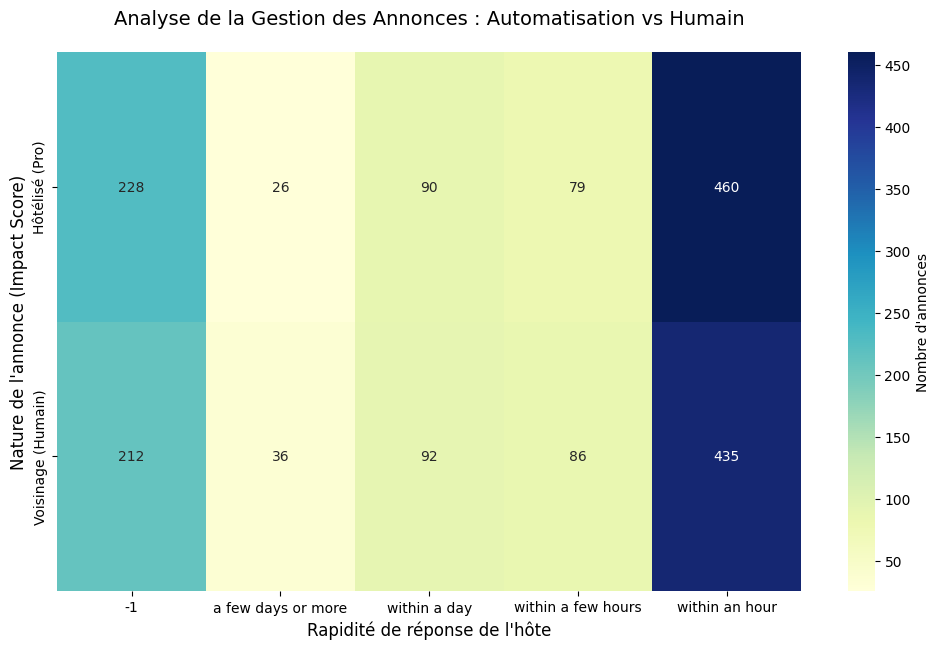

 Analyse basée sur 1744 annonces du quartier Élysée.


In [35]:
# 1. Nettoyage des noms de colonnes
df.columns = [c.lower().strip() for c in df.columns]

# 2. Identification des colonnes
col_impact = next((c for c in df.columns if 'impact' in c), None)
col_response = next((c for c in df.columns if 'response_time' in c), None)

if col_impact and col_response:
    # 3. Préparation des données et mapping pour la clarté
    # On filtre les -1 (données non disponibles)
    df_clean = df[(df[col_impact] != -1) & (df[col_impact].notnull()) & (df[col_response].notnull())].copy()
    
    # Mapping des labels pour les axes (à adapter selon tes valeurs réelles)
    impact_labels = {0: "Voisinage (Humain)", 1: "Hôtélisé (Pro)"}
    # On s'assure que le temps de réponse est bien lisible
    df_clean['impact_label'] = df_clean[col_impact].map(impact_labels)

    if not df_clean.empty:
        # 4. Création du tableau croisé
        ct = pd.crosstab(df_clean['impact_label'], df_clean[col_response])
        
        # 5. Affichage de la Heatmap enrichie
        plt.figure(figsize=(12, 7))
        sns.heatmap(ct, annot=True, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Nombre d\'annonces'})
        
        plt.title("Analyse de la Gestion des Annonces : Automatisation vs Humain", fontsize=14, pad=20)
        plt.xlabel("Rapidité de réponse de l'hôte", fontsize=12)
        plt.ylabel("Nature de l'annonce (Impact Score)", fontsize=12)
        plt.show()
        
        print(f" Analyse basée sur {len(df_clean)} annonces du quartier Élysée.")
    else:
        print(" Erreur : Les filtres ont éliminé toutes les données.")
else:
    print(f"⚠️ Colonnes manquantes. Vérifie l'import SQL.")